# EXP026 RMSE comparison

`item_bank_uncor_1.csv` 上のMFI、EXP020、EXP023、EXP026を比較する。



In [2]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd


def find_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for root in [cwd, *cwd.parents]:
        if (root / "data").is_dir() and (root / "EXP026").is_dir():
            return root
    raise FileNotFoundError("Run this notebook inside the repository.")


def load_if_exists(path: Path) -> pd.DataFrame | None:
    if not path.exists():
        print(f"NOT FOUND (skipped): {path}")
        return None
    return pd.read_csv(path)


def rmse_at(data: pd.DataFrame, steps: list[int]) -> list[float]:
    integer_steps = data["step"].round().astype(int)
    return [
        float(data.loc[integer_steps == step, "RMSE"].iloc[0])
        if (integer_steps == step).any()
        else float("nan")
        for step in steps
    ]


ROOT = find_project_root()
EXP007_RESULTS = ROOT / "EXP007" / "results"
EXP020_RESULTS = ROOT / "EXP020" / "results"
EXP023_RESULTS = ROOT / "EXP023" / "results"
EXP026_RESULTS = ROOT / "EXP026" / "results"

BANK_ID = 1
GAMMA = "0.1"
SEED = 42
KEY_STEPS = [10, 20, 30, 40]

mfi = pd.read_csv(EXP007_RESULTS / f"summary_uncor_{BANK_ID}_MFI.csv")
exp020 = load_if_exists(
    EXP020_RESULTS / f"summary_uncor_{BANK_ID}_DQN_normal_gamma_{GAMMA}.csv"
)
exp023 = load_if_exists(
    EXP023_RESULTS
    / (f"summary_uncor_{BANK_ID}_DQN_Param_Raw_normal_gamma_{GAMMA}_seed_{SEED}.csv")
)
exp026 = load_if_exists(
    EXP026_RESULTS
    / (
        f"summary_uncor_{BANK_ID}_Double_DQN_Param_Raw_"
        f"normal_gamma_{GAMMA}_seed_{SEED}.csv"
    )
)

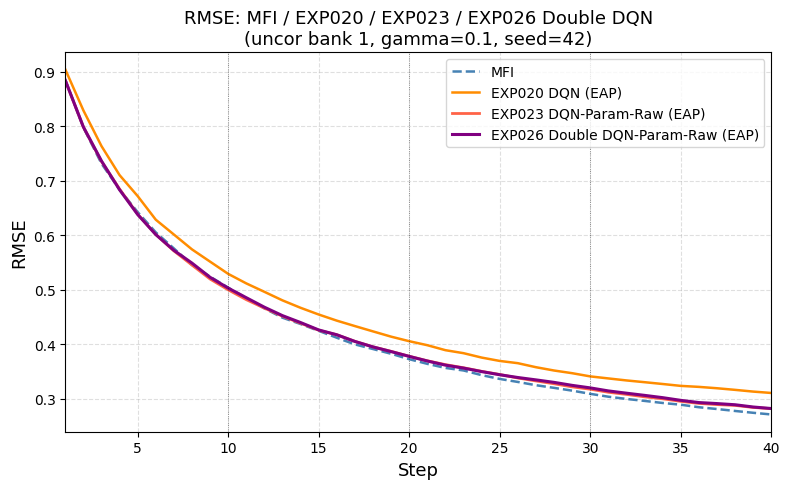

Saved to: /Users/itsuki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History/EXP026/results/rmse_comparison_uncor_1_gamma_0.1_seed_42.png


In [3]:
series = [
    (mfi, "MFI", "steelblue", "--", 1.8),
    (exp020, "EXP020 DQN (EAP)", "darkorange", "-", 1.8),
    (exp023, "EXP023 DQN-Param-Raw (EAP)", "tomato", "-", 2.0),
    (exp026, "EXP026 Double DQN-Param-Raw (EAP)", "purple", "-", 2.2),
]

figure, axis = plt.subplots(figsize=(8, 5))
for data, label, color, line_style, line_width in series:
    if data is not None:
        axis.plot(
            data["step"],
            data["RMSE"],
            label=label,
            color=color,
            linestyle=line_style,
            linewidth=line_width,
        )

for step in KEY_STEPS:
    axis.axvline(step, color="black", linewidth=0.6, linestyle=":", alpha=0.5)

axis.set_xlabel("Step", fontsize=13)
axis.set_ylabel("RMSE", fontsize=13)
axis.set_title(
    "RMSE: MFI / EXP020 / EXP023 / EXP026 Double DQN\n"
    f"(uncor bank {BANK_ID}, gamma={GAMMA}, seed={SEED})",
    fontsize=13,
)
axis.legend(fontsize=10)
axis.grid(True, linestyle="--", alpha=0.4)
axis.xaxis.set_major_locator(mticker.MultipleLocator(5))
axis.set_xlim(1, 40)

figure.tight_layout()
EXP026_RESULTS.mkdir(parents=True, exist_ok=True)
output_path = (
    EXP026_RESULTS / f"rmse_comparison_uncor_{BANK_ID}_gamma_{GAMMA}_seed_{SEED}.png"
)
figure.savefig(output_path, dpi=150)
plt.show()
print(f"Saved to: {output_path}")

In [4]:
rows = []
for data, label, *_ in series:
    if data is not None:
        rows.append({"method": label, **dict(zip(KEY_STEPS, rmse_at(data, KEY_STEPS)))})

comparison = pd.DataFrame(rows).set_index("method")
comparison.columns.name = "step"
print(comparison.to_string(float_format="{:.3f}".format))

step                                 10    20    30    40
method                                                   
MFI                               0.504 0.372 0.309 0.271
EXP020 DQN (EAP)                  0.529 0.406 0.341 0.310
EXP023 DQN-Param-Raw (EAP)        0.500 0.378 0.317 0.282
EXP026 Double DQN-Param-Raw (EAP) 0.503 0.378 0.320 0.282
